# ⚠️ IMPORTANT: RUN CELLS IN ORDER!

# Traffic Accident Prediction in Calgary Using Weather Data
## ENGG 680 - Group 25

## Preliminary: Certificate of Work


*We, the undersigned, certify that this is our own work, which has been done expressly for this course, either without the assistance of any other party or where appropriate we have acknowledged the work of others. Further, we have read and understood the section in the university calendar on plagiarism/cheating/other academic misconduct and we are aware of the implications thereof. We request that the total mark for this assignment be distributed as follows among group members:*

|          | First Name | Last Name | Signature (Full Name, Date) | Hours | Contribution % |
|----------|------------|-----------|-----------------------------|-------|----------------|
| Member 1: | Johir Babor | Babor | Babor | 17 | 33% |
| Member 2: | Bhaskar | Ketha | Bhaskar | 17 | 33% |
| Member 3: | Taha | Fathizedh | Taha | 17 | 33% |


## STEP-1: Import Libraries

In [20]:
print('\n📚 CELL 1: Import Libraries')
print('-'*70)

import pandas as pd
import numpy as np
from datetime import datetime

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, roc_auc_score, roc_curve

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

print('✅ Libraries imported successfully!')


📚 CELL 1: Import Libraries
----------------------------------------------------------------------
✅ Libraries imported successfully!


## STEP-2 : Mount Google Drive

In [21]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## STEP-3: Load Traffic Data

In [22]:
print('\n' + '='*70)
print('📊 CELL 3: Load Traffic Data')
print('-'*70)

try:
    incidents_df = pd.read_csv('/content/drive/MyDrive/ENGG680_2025_Fall/Project Report/Traffic_Incidents_20251205.csv')
    print(f'✅ Loaded {len(incidents_df):,} traffic incidents')
    print(f'   Columns: {list(incidents_df.columns)}')
    print(f'   Shape: {incidents_df.shape}')
except FileNotFoundError as e:
    print(f'❌ ERROR: Traffic file not found!')
    raise


📊 CELL 3: Load Traffic Data
----------------------------------------------------------------------
✅ Loaded 6,148 traffic incidents
   Columns: ['INCIDENT INFO', 'DESCRIPTION', 'START_DT', 'MODIFIED_DT', 'QUADRANT', 'Longitude', 'Latitude', 'Count', 'id', 'Point']
   Shape: (6148, 10)


## STEP-4: Preprocess Traffic Data

In [23]:
print('\n' + '='*70)
print('🔧 CELL 4: Preprocess Traffic Data')
print('-'*70)

incidents_df['START_DT'] = pd.to_datetime(
    incidents_df['START_DT'],
    format='%m/%d/%Y %H:%M',
    errors='coerce'
)
incidents_df = incidents_df.dropna(subset=['START_DT'])

incidents_df['year'] = incidents_df['START_DT'].dt.year
incidents_df['month'] = incidents_df['START_DT'].dt.month
incidents_df['day'] = incidents_df['START_DT'].dt.day
incidents_df['hour'] = incidents_df['START_DT'].dt.hour
incidents_df['day_of_week'] = incidents_df['START_DT'].dt.dayofweek
incidents_df['date'] = incidents_df['START_DT'].dt.date

# Filter November 2025
incidents_nov = incidents_df[(incidents_df['year'] == 2025) & (incidents_df['month'] == 11)].copy()

print(f'✅ Filtered to November 2025: {len(incidents_nov):,} incidents')
if len(incidents_nov) > 0:
    print(f'   Date range: {incidents_nov["START_DT"].min()} to {incidents_nov["START_DT"].max()}')


🔧 CELL 4: Preprocess Traffic Data
----------------------------------------------------------------------
✅ Filtered to November 2025: 813 incidents
   Date range: 2025-11-01 04:43:00 to 2025-11-30 23:23:00


## STEP-5: Load Weather Data

In [24]:
print('\n' + '='*70)
print('🌤️  CELL 5: Load Weather Data')
print('-'*70)

try:
    weather_df = pd.read_csv('/content/drive/MyDrive/ENGG680_2025_Fall/Project Report/en_climate_hourly_AB_3031092_11-2025_P1H.csv')
    print(f'✅ Loaded {len(weather_df):,} weather observations')
    print(f'   Columns: {len(weather_df.columns)} columns')
    print(f'   Shape: {weather_df.shape}')
except FileNotFoundError as e:
    print(f'❌ ERROR: Weather file not found!')
    raise


🌤️  CELL 5: Load Weather Data
----------------------------------------------------------------------
✅ Loaded 720 weather observations
   Columns: 31 columns
   Shape: (720, 31)


## STEP-6: Preprocess Weather Data

In [25]:
print('\n' + '='*70)
print('🔧 CELL 6: Preprocess Weather Data')
print('-'*70)

weather_df['datetime'] = pd.to_datetime(weather_df['Date/Time (LST)'], format='%Y-%m-%d %H:%M', errors='coerce')
weather_df['date'] = weather_df['datetime'].dt.date
weather_df['hour'] = weather_df['datetime'].dt.hour

weather_df = weather_df.rename(columns={
    'Temp (°C)': 'temp',
    'Dew Point Temp (°C)': 'dew_point',
    'Rel Hum (%)': 'humidity',
    'Precip. Amount (mm)': 'precip',
    'Wind Spd (km/h)': 'wind_speed',
    'Visibility (km)': 'visibility',
    'Stn Press (kPa)': 'pressure',
    'Weather': 'weather_condition'
})

weather_clean = weather_df[[
    'datetime', 'date', 'hour', 'temp', 'dew_point', 'humidity',
    'precip', 'wind_speed', 'visibility', 'pressure', 'weather_condition'
]].copy()

numeric_cols = ['temp', 'dew_point', 'humidity', 'precip', 'wind_speed', 'visibility', 'pressure']
for col in numeric_cols:
    weather_clean[col] = pd.to_numeric(weather_clean[col], errors='coerce')

for col in numeric_cols:
    weather_clean[col] = weather_clean[col].ffill().bfill().fillna(weather_clean[col].median())

print(f'✅ Weather data cleaned: {len(weather_clean):,} observations')


🔧 CELL 6: Preprocess Weather Data
----------------------------------------------------------------------
✅ Weather data cleaned: 720 observations


## STEP- 7: Create Hourly Counts

In [26]:
print('\n' + '='*70)
print('⏰ CELL 7: Create Hourly Counts')
print('-'*70)

incidents_hourly = incidents_nov.groupby(['date', 'hour']).size().reset_index(name='incident_count')
print(f'✅ Created {len(incidents_hourly):,} hourly incident records')
print(f'   Total hours in data: {len(weather_clean)}')


⏰ CELL 7: Create Hourly Counts
----------------------------------------------------------------------
✅ Created 388 hourly incident records
   Total hours in data: 720


## STEP-8: Merge Data

In [27]:
print('\n' + '='*70)
print('🔗 CELL 8: Merge Data')
print('-'*70)

merged_df = weather_clean.merge(incidents_hourly, on=['date', 'hour'], how='left')
merged_df['incident_count'] = merged_df['incident_count'].fillna(0).astype(int)
merged_df['incident_occurred'] = (merged_df['incident_count'] > 0).astype(int)

print(f'✅ Merged dataset: {len(merged_df):,} records')
print(f'   Incident rate: {merged_df["incident_occurred"].mean()*100:.2f}%')
print(f'   Incident distribution: {merged_df["incident_occurred"].value_counts().to_dict()}')


🔗 CELL 8: Merge Data
----------------------------------------------------------------------
✅ Merged dataset: 720 records
   Incident rate: 53.89%
   Incident distribution: {1: 388, 0: 332}


## STEP-9: Feature Engineering

In [28]:
print('\n' + '='*70)
print('⚙️  CELL 9: Feature Engineering')
print('-'*70)

# Temporal features
merged_df['day_of_week'] = pd.to_datetime(merged_df['datetime']).dt.dayofweek
merged_df['is_weekend'] = (merged_df['day_of_week'] >= 5).astype(int)
merged_df['hour_of_day'] = merged_df['hour']
merged_df['is_rush_hour'] = merged_df['hour_of_day'].apply(lambda x: 1 if (7 <= x <= 9) or (16 <= x <= 18) else 0)

# Weather indicators
merged_df['is_freezing'] = (merged_df['temp'] <= 0).astype(int)
merged_df['has_precip'] = (merged_df['precip'] > 0).astype(int)
merged_df['poor_visibility'] = (merged_df['visibility'] < 5).astype(int)
merged_df['high_wind'] = (merged_df['wind_speed'] > 30).astype(int)

# Derived features
merged_df['temp_change'] = merged_df['temp'].diff().fillna(0)
merged_df['pressure_change'] = merged_df['pressure'].diff().fillna(0)
merged_df['temp_precip'] = merged_df['temp'] * merged_df['precip']
merged_df['visibility_precip'] = merged_df['visibility'] * merged_df['precip']
merged_df['freezing_precip'] = merged_df['is_freezing'] * merged_df['has_precip']

print('✅ Created 20 features:')
print('   - 7 Weather variables')
print('   - 4 Temporal features')
print('   - 5 Derived features')


⚙️  CELL 9: Feature Engineering
----------------------------------------------------------------------
✅ Created 20 features:
   - 7 Weather variables
   - 4 Temporal features
   - 5 Derived features


## STEP-10: Prepare Data

In [29]:
print('\n' + '='*70)
print('📋 CELL 10: Prepare Data')
print('-'*70)

feature_cols = [
    'temp', 'dew_point', 'humidity', 'precip', 'wind_speed', 'visibility', 'pressure',
    'hour_of_day', 'day_of_week', 'is_weekend', 'is_rush_hour',
    'temp_change', 'pressure_change',
    'is_freezing', 'has_precip', 'poor_visibility', 'high_wind', 'freezing_precip',
    'temp_precip', 'visibility_precip'
]

X = merged_df[feature_cols].copy()
y = merged_df['incident_occurred'].copy()

# Fill NaN values
X = X.ffill().bfill()
X = X.fillna(X.median(numeric_only=True))
X = X.fillna(0)

print(f'✅ Features prepared: {X.shape}')
print(f'✅ Target prepared: {y.shape}')


📋 CELL 10: Prepare Data
----------------------------------------------------------------------
✅ Features prepared: (720, 20)
✅ Target prepared: (720,)


## STEP-11: Train-Test Split

In [30]:
print('\n' + '='*70)
print('✂️  CELL 11: Train-Test Split')
print('-'*70)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, shuffle=True
)

print(f'✅ Training set: {len(X_train):,} samples ({y_train.mean()*100:.2f}% incidents)')
print(f'✅ Test set: {len(X_test):,} samples ({y_test.mean()*100:.2f}% incidents)')


✂️  CELL 11: Train-Test Split
----------------------------------------------------------------------
✅ Training set: 576 samples (53.30% incidents)
✅ Test set: 144 samples (56.25% incidents)


## STEP-12: Scale Features

In [31]:
print('\n' + '='*70)
print('📐 CELL 12: Scale Features')
print('-'*70)

scaler = StandardScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=feature_cols,
    index=X_train.index
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=feature_cols,
    index=X_test.index
)

print('✅ Features scaled using StandardScaler')
print(f'   Mean: {X_train_scaled.mean().mean():.6f}')
print(f'   Std: {X_train_scaled.std().mean():.6f}')


📐 CELL 12: Scale Features
----------------------------------------------------------------------
✅ Features scaled using StandardScaler
   Mean: 0.000000
   Std: 0.750652


## STEP-13: Train Models

In [32]:
print('\n' + '='*70)
print('🤖 CELL 13: Train Models')
print('⏳ This may take ~60 seconds...')
print('-'*70)

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(max_depth=5, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=200, max_depth=15, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=200, max_depth=3, learning_rate=0.01, random_state=42)
}

trained_models = {}
for name, model in models.items():
    print(f'  Training {name}...')
    model.fit(X_train_scaled, y_train)
    trained_models[name] = model

print('\n✅ All 4 models trained successfully!')


🤖 CELL 13: Train Models
⏳ This may take ~60 seconds...
----------------------------------------------------------------------
  Training Logistic Regression...
  Training Decision Tree...
  Training Random Forest...
  Training Gradient Boosting...

✅ All 4 models trained successfully!


## STEP-14: Generate Predictions

In [33]:
print('\n' + '='*70)
print('🎯 CELL 14: Generate Predictions')
print('-'*70)

predictions = {}
probabilities = {}

for name, model in trained_models.items():
    predictions[name] = model.predict(X_test_scaled)
    if hasattr(model, 'predict_proba'):
        probabilities[name] = model.predict_proba(X_test_scaled)[:, 1]

print('✅ Predictions generated for all models')


🎯 CELL 14: Generate Predictions
----------------------------------------------------------------------
✅ Predictions generated for all models


## STEP-15: Evaluate Performance

In [34]:
print('\n' + '='*70)
print('📊 CELL 15: Evaluate Performance')
print('='*70)

results = []
for name in trained_models.keys():
    y_pred = predictions[name]
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)

    if name in probabilities:
        roc_auc = roc_auc_score(y_test, probabilities[name])
        roc_auc_str = f'{roc_auc:.4f}'
    else:
        roc_auc_str = 'N/A'

    results.append({
        'Model': name,
        'Accuracy': f'{acc:.4f}',
        'Precision': f'{prec:.4f}',
        'Recall': f'{rec:.4f}',
        'F1-Score': f'{f1:.4f}',
        'ROC-AUC': roc_auc_str
    })

results_df = pd.DataFrame(results)
print('\nMODEL PERFORMANCE')
print('='*90)
print(results_df.to_string(index=False))
print('='*90)


📊 CELL 15: Evaluate Performance

MODEL PERFORMANCE
              Model Accuracy Precision Recall F1-Score ROC-AUC
Logistic Regression   0.6111    0.6344 0.7284   0.6782  0.6234
      Decision Tree   0.6389    0.7042 0.6173   0.6579  0.6399
      Random Forest   0.6806    0.7059 0.7407   0.7229  0.7370
  Gradient Boosting   0.6736    0.7179 0.6914   0.7044  0.6995


## STEP-16: Confusion Matrices


📈 CELL 16: Confusion Matrices
----------------------------------------------------------------------


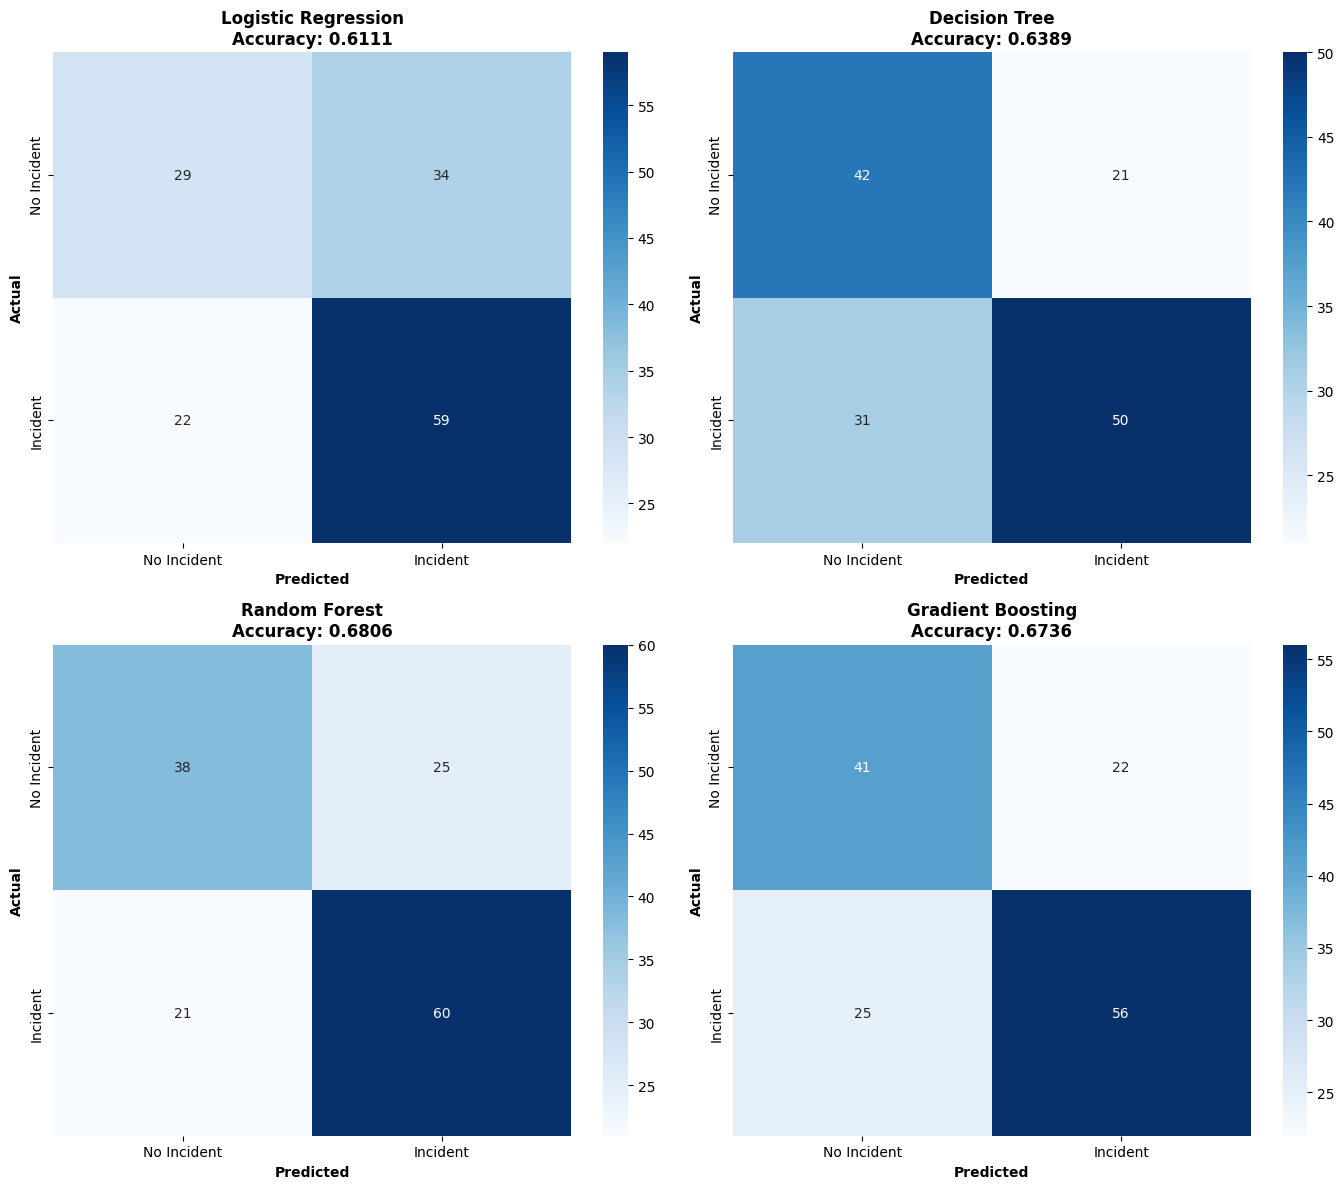

✅ Displayed: Confusion Matrices


In [35]:
print('\n' + '='*70)
print('📈 CELL 16: Confusion Matrices')
print('-'*70)

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.ravel()

for idx, (name, y_pred) in enumerate(predictions.items()):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                xticklabels=['No Incident', 'Incident'],
                yticklabels=['No Incident', 'Incident'])
    acc = accuracy_score(y_test, y_pred)
    axes[idx].set_title(f'{name}\nAccuracy: {acc:.4f}', fontweight='bold', fontsize=12)
    axes[idx].set_ylabel('Actual', fontweight='bold')
    axes[idx].set_xlabel('Predicted', fontweight='bold')

plt.tight_layout()
plt.show()
print('✅ Displayed: Confusion Matrices')

## STEP-17: ROC Curves

📉 CELL 17: ROC Curves
----------------------------------------------------------------------


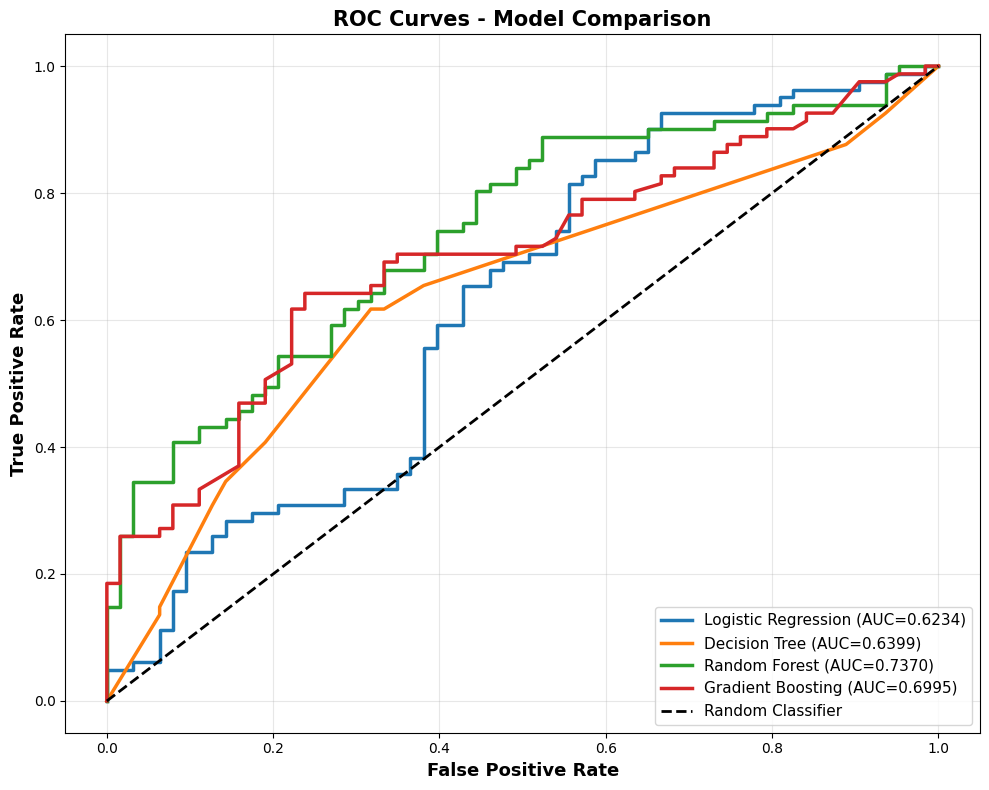

✅ Displayed: ROC Curves


In [36]:
print('📉 CELL 17: ROC Curves')
print('-'*70)

plt.figure(figsize=(10, 8))
for name in probabilities.keys():
    fpr, tpr, _ = roc_curve(y_test, probabilities[name])
    auc = roc_auc_score(y_test, probabilities[name])
    plt.plot(fpr, tpr, label=f'{name} (AUC={auc:.4f})', linewidth=2.5)

plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier', linewidth=2)
plt.xlabel('False Positive Rate', fontsize=13, fontweight='bold')
plt.ylabel('True Positive Rate', fontsize=13, fontweight='bold')
plt.title('ROC Curves - Model Comparison', fontsize=15, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()
print('✅ Displayed: ROC Curves')

## STEP-18: Feature Importance


⭐ CELL 18: Feature Importance
----------------------------------------------------------------------

TOP 10 FEATURES
                 Decision Tree  Random Forest  Gradient Boosting   Average
hour_of_day           0.536249       0.180893           0.602838  0.439993
dew_point             0.117035       0.104930           0.039380  0.087115
day_of_week           0.105480       0.056750           0.098817  0.087016
temp                  0.092085       0.099791           0.029541  0.073806
pressure              0.043468       0.108392           0.068522  0.073460
wind_speed            0.034926       0.079086           0.061942  0.058651
humidity              0.019405       0.091004           0.051075  0.053828
temp_change           0.042038       0.102932           0.011647  0.052206
pressure_change       0.000000       0.078723           0.032891  0.037205
visibility            0.000000       0.046555           0.003345  0.016633


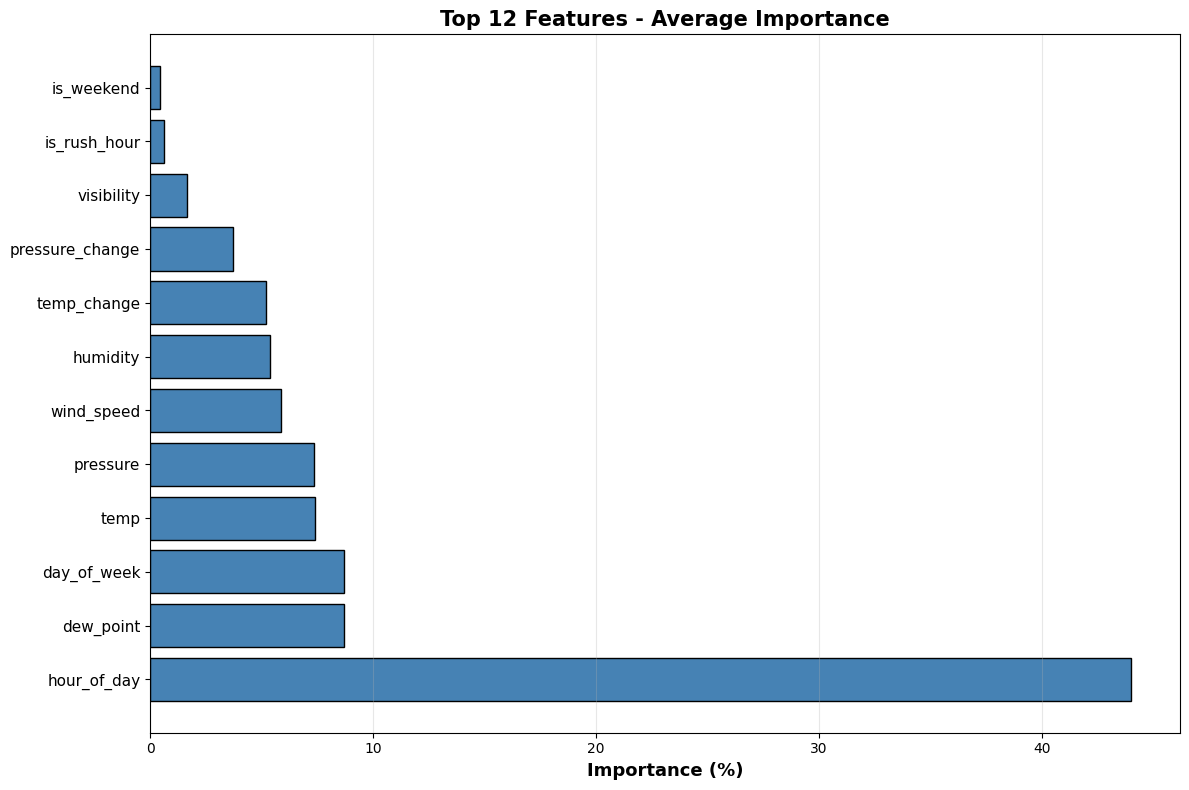


✅ Displayed: Feature Importance Chart


In [37]:
print('\n' + '='*70)
print('⭐ CELL 18: Feature Importance')
print('-'*70)

feature_importance_data = {}
for name, model in trained_models.items():
    if hasattr(model, 'feature_importances_'):
        feature_importance_data[name] = model.feature_importances_

if feature_importance_data:
    feature_importance_df = pd.DataFrame(feature_importance_data, index=feature_cols)
    feature_importance_df['Average'] = feature_importance_df.mean(axis=1)
    feature_importance_df = feature_importance_df.sort_values('Average', ascending=False)

    print('\nTOP 10 FEATURES')
    print('='*70)
    print(feature_importance_df.head(10).to_string())
    print('='*70)

    plt.figure(figsize=(12, 8))
    top_features = feature_importance_df.head(12)
    plt.barh(range(len(top_features)), top_features['Average'] * 100, color='steelblue', edgecolor='black')
    plt.yticks(range(len(top_features)), top_features.index, fontsize=11)
    plt.xlabel('Importance (%)', fontsize=13, fontweight='bold')
    plt.title('Top 12 Features - Average Importance', fontsize=15, fontweight='bold')
    plt.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()
    print('\n✅ Displayed: Feature Importance Chart')

## PROJECT COMPLETE

In [38]:
print('\n' + '='*70)
print('✅ PROJECT COMPLETE!')
print('='*70)
print('\n📊 Results Summary:')
best_model = results_df.loc[results_df['Accuracy'].astype(float).idxmax()]
print(f'  Best Model: {best_model["Model"]}')
print(f'  Accuracy: {best_model["Accuracy"]}')
print(f'  ROC-AUC: {best_model["ROC-AUC"]}')
print(f'\n📈 Top Feature: {feature_importance_df.index[0]}')
print(f'  Importance: {feature_importance_df.iloc[0]["Average"]*100:.2f}%')
print('\n' + '='*70)
print('ENGG 680 - Group 25')
print('='*70)


✅ PROJECT COMPLETE!

📊 Results Summary:
  Best Model: Random Forest
  Accuracy: 0.6806
  ROC-AUC: 0.7370

📈 Top Feature: hour_of_day
  Importance: 44.00%

ENGG 680 - Group 25
